<a href="https://colab.research.google.com/github/braadly/EEL4810_Project1/blob/main/Group4NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset is located within shared google drive. Sign in to access.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.path.exists('/content/drive/MyDrive/train'))
print(os.listdir('/content/drive/MyDrive/train'))

True
['Glioblastoma', 'Metastatic', 'Schwannoma', 'glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


Using device: cpu
Total images:  7897
Classes found: ['Glioblastoma', 'Metastatic', 'Schwannoma', 'glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Class mapping: {'Glioblastoma': 0, 'Metastatic': 1, 'Schwannoma': 2, 'glioma_tumor': 3, 'meningioma_tumor': 4, 'no_tumor': 5, 'pituitary_tumor': 6}
Train samples: 6317  Val samples: 790  Test samples: 790
Data Loaded!


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 147MB/s]

Model Initialised!



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Starting Testing!
Duration of test computation:  94.4799211025238  sec


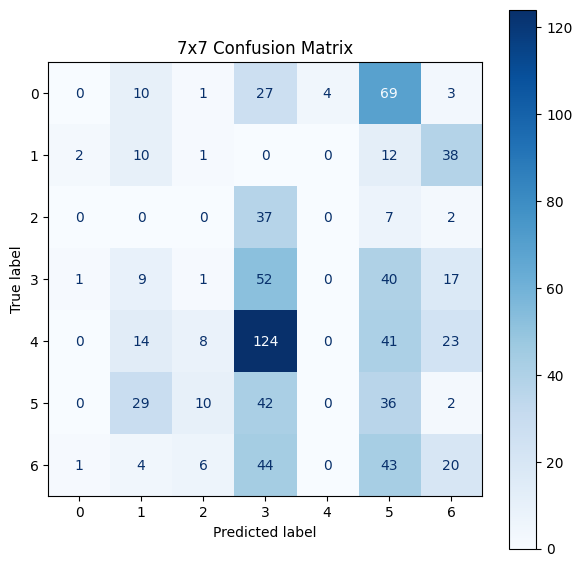

Macro F1: 0.10751803314307605


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
import torch.nn.functional as F
import time
import torch.nn.init as init
import matplotlib.pyplot as plt

torch.manual_seed(73)
np.random.seed(73)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---------- load dataset ---------- #
# location of the drive in my personal google drive -Bradly
# the way i set this up, is after Ethan shared the drive with me
# right click the folder, organize, add shortcut, then add it onto
# 'myDrive'

# loaded

DATASET_PATH = '/content/drive/MyDrive/train'

train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

full_dataset = ImageFolder(root=DATASET_PATH, transform=train_transforms)
N = len(full_dataset)

print(f"Total images:  {len(full_dataset)}")
print(f"Classes found: {full_dataset.classes}")
print(f"Class mapping: {full_dataset.class_to_idx}")

train_idx = [i for i in range(N) if i % 10 not in (0, 1)]
val_idx = list(range(1, N, 10))
test_idx = list(range(0, N, 10))

train_len = len(train_idx)
val_len = len(val_idx)
test_len = len(test_idx)
print(f"Train samples: {train_len}  Val samples: {val_len}  Test samples: {test_len}")

train_ds = Subset(full_dataset, train_idx)
val_ds = Subset(full_dataset, val_idx)
test_ds = Subset(full_dataset, test_idx)

batch_size = 790
num_workers = 4
train_load = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True, persistent_workers=True)
val_load = DataLoader(val_ds,  batch_size=val_len, shuffle=False, num_workers=max(1, num_workers//2), pin_memory=True, persistent_workers=True)
test_load = DataLoader(test_ds,  batch_size=test_len, shuffle=False, num_workers=max(1, num_workers//2), pin_memory=True, persistent_workers=True)

print("Data Loaded!")

# ---------- set up resnet18 neural network ---------- #
model = models.resnet18(pretrained=True) # sets up resnet18 pretrained model

model.fc = nn.Linear(model.fc.in_features, 7) # creates output layer (7 outputs; one for each classification)

init.kaiming_normal_(model.fc.weight, mode='fan_in', nonlinearity='relu')
init.zeros_(model.fc.bias) # initialises output layer weights (randoms for ReLu) and biases (zeros)

model = model.to(device) # move the model to the GPU

print("Model Initialised!")

# ---------- fine tune model using LoRA rank-4 ---------- # (no need to set up until after midterm report)


# ---------- Training loop ---------- #

'''
labels_list = [label for _, label in full_dataset.samples]
class_counts = Counter(labels_list)
total_samples = sum(class_counts.values())
weights = [total_samples / class_counts[i] for i in range(7)]
weights = torch.tensor(weights, dtype=torch.float).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.0002)
criterion = nn.CrossEntropyLoss(weight=weights)

NUM_EPOCHS = 20
best_f1 = 0

for epoch in range(NUM_EPOCHS):
    # train
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # validate
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | Macro-F1: {macro_f1:.4f}")

    if macro_f1 > best_f1:
        best_f1 = macro_f1
        torch.save(model.state_dict(), '/content/drive/MyDrive/best_model.pth')
        print(f"  New best model saved! F1: {best_f1:.4f}")
'''

# implement method to save and load trained networks? (depending on how long training takes, we may not need this)


# ---------- test with Macro-F1 value and graphs ---------- #

model.eval() # warm up GPU if available; this code generated with prompt: "For a resnet18 model, write a short program to warm up the GPU"
with torch.no_grad():
    # warm-up iterations
    if device.type == 'cuda':
        for _ in range(3):
            _ = model(torch.randn(8, 3, 224, 224, device=device))


test_set = iter(test_load)
cur_batch, targets = next(test_set) # load the test set for testing
cur_batch = cur_batch.to(device, non_blocking=True)

t = time.time()
print("Starting Testing!")

with torch.no_grad(): # run the test batch through the model
    logits = model(cur_batch)
torch.cuda.synchronize() if device.type == 'cuda' else None

dt = time.time() - t
print("Duration of test computation: ", dt, " sec")

preds = torch.argmax(logits, dim=1) # find the index of the largest output for each image

preds_cpu = preds.cpu().numpy()
targets_cpu = targets.cpu().numpy()

labels = list(range(7))
cm = confusion_matrix(targets_cpu, preds_cpu, labels=labels) # create confusion matrix for viewing

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels) # display confusion matrix
fig, ax = plt.subplots(figsize=(7,7))
disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
plt.title("7x7 Confusion Matrix")
plt.show()

macro_f1 = f1_score(targets_cpu, preds_cpu, labels=list(range(7)), average='macro', zero_division=0) # calculate the Macro-F1 score of the test set and display it
print("Macro F1:", macro_f1)

